In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
dataSet=pd.read_csv('/content/Food_Delivery_Times.csv')

In [ ]:
dataSet

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [ ]:
print('Missing values before handling:')
print(dataSet.isnull().sum())

Missing values before handling:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [ ]:
dataSet.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [ ]:
# Fill null values for categorical columns with their mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    mode_value = dataSet[col].mode()[0]
    dataSet[col].fillna(mode_value, inplace=True)

# Fill null values for numerical column 'Courier_Experience_yrs' with its mean
dataSet['Courier_Experience_yrs'].fillna(dataSet['Courier_Experience_yrs'].median(), inplace=True)

# Drop the 'Order_ID' column
dataSet.drop('Order_ID', axis=1, inplace=True)

print('Missing values after handling and dropping Order_ID:')
print(dataSet.isnull().sum())

Missing values after handling and dropping Order_ID:
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


# EDA

In [ ]:
display(dataSet.describe())

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.592000,56.732000
std,5.696656,7.204553,2.871198,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


Text(0, 0.5, 'Frequency')

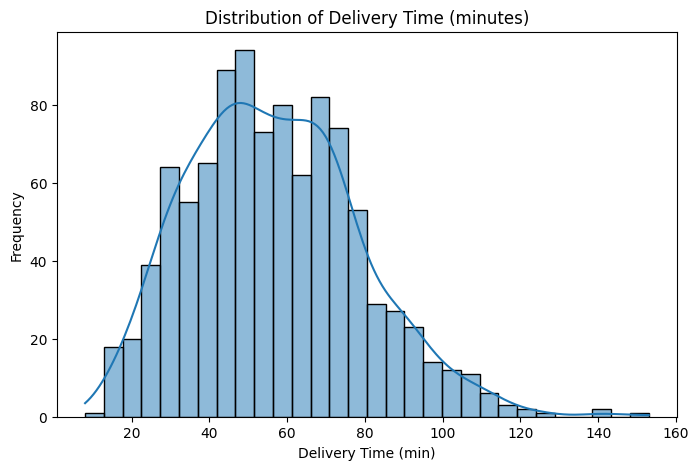

In [ ]:
# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(dataSet['Delivery_Time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')

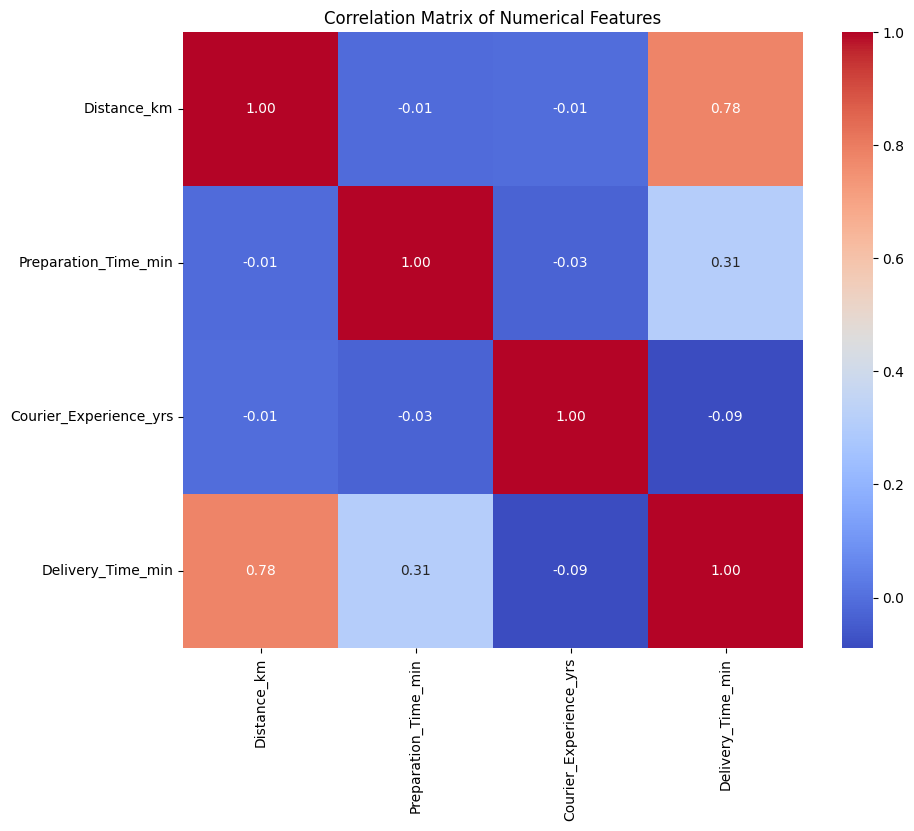

In [ ]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(dataSet.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

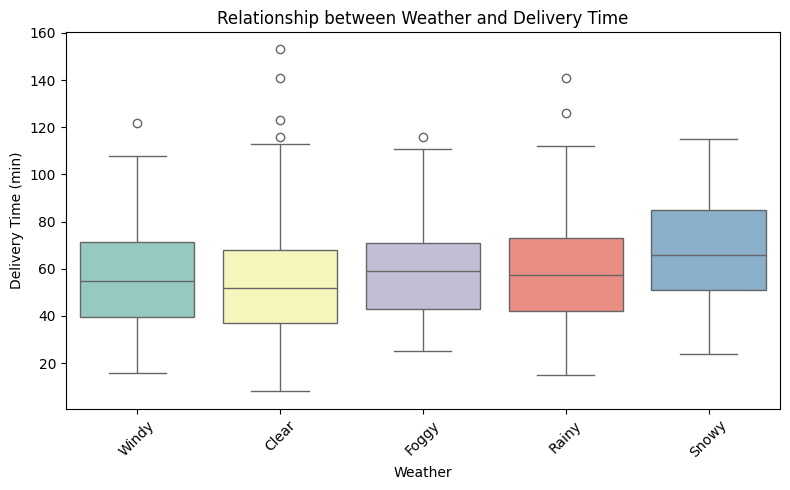

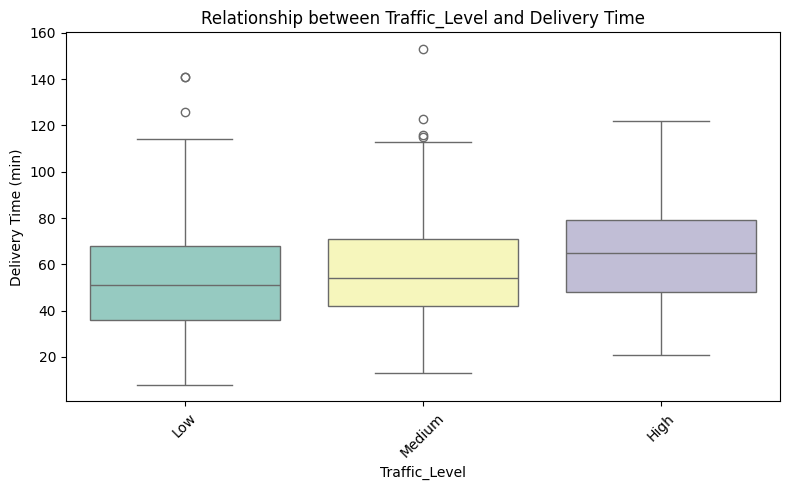

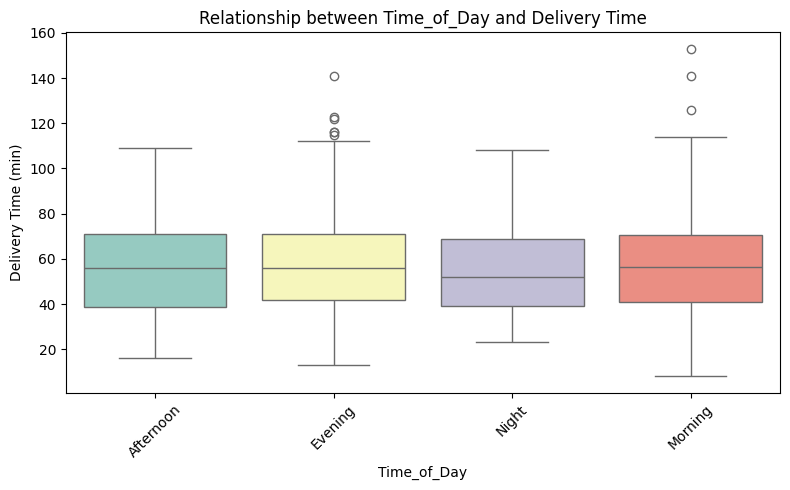

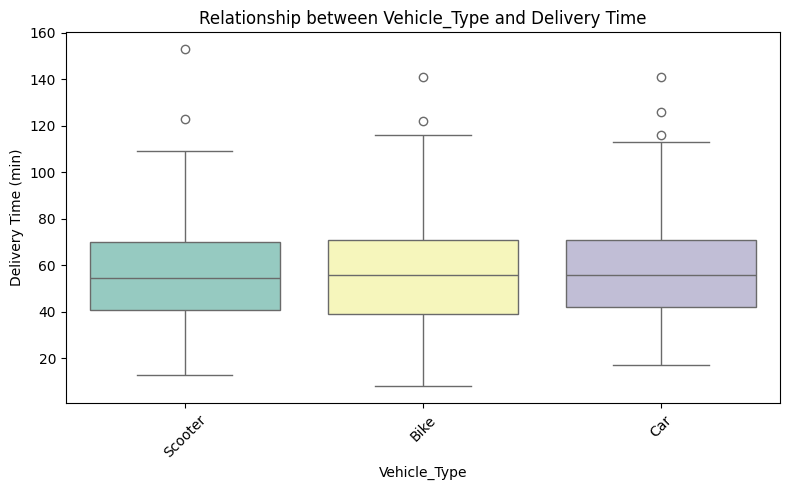

In [ ]:
#BoxPlot(Relationship between Categorical Features and Delivery Time)

for col in ['Weather', 'Traffic_Level', 'Time_of_Day','Vehicle_Type']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=col, y='Delivery_Time_min', data=dataSet, palette='Set3')
    plt.title(f'Relationship between {col} and Delivery Time')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Statistical Testing for Feature Importance

In [ ]:
from scipy.stats import f_oneway

categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

print('ANOVA Test Results (Categorical Features vs. Delivery_Time_min):\n')
for col in categorical_cols:
    groups = [dataSet['Delivery_Time_min'][dataSet[col] == category] for category in dataSet[col].unique()]
    f_stat, p_value = f_oneway(*groups)
    print(f'Feature: {col}')
    print(f'  F-statistic: {f_stat:.2f}')
    print(f'  P-value: {p_value:.3f}')
    if p_value < 0.05:
        print(f'  Result: Significant (reject H0 - different means)')
    else:
        print(f'  Result: Not significant (fail to reject H0 - similar means)')
    print('-' * 40)

ANOVA Test Results (Categorical Features vs. Delivery_Time_min):

Feature: Weather
  F-statistic: 10.50
  P-value: 0.000
  Result: Significant (reject H0 - different means)
----------------------------------------
Feature: Traffic_Level
  F-statistic: 19.75
  P-value: 0.000
  Result: Significant (reject H0 - different means)
----------------------------------------
Feature: Time_of_Day
  F-statistic: 0.35
  P-value: 0.792
  Result: Not significant (fail to reject H0 - similar means)
----------------------------------------
Feature: Vehicle_Type
  F-statistic: 0.59
  P-value: 0.555
  Result: Not significant (fail to reject H0 - similar means)
----------------------------------------


### Correlation of Numerical Features with `Delivery_Time_min`

In [ ]:
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

print('Correlation of Numerical Features with Delivery_Time_min:\n')
correlation_with_target = dataSet[numerical_cols + ['Delivery_Time_min']].corr()['Delivery_Time_min'].drop('Delivery_Time_min')
print(correlation_with_target.sort_values(ascending=False))

Correlation of Numerical Features with Delivery_Time_min:

Distance_km               0.780998
Preparation_Time_min      0.307350
Courier_Experience_yrs   -0.089111
Name: Delivery_Time_min, dtype: float64


### Data Preparation for Modeling: Feature Engineering and Train-Test Split

### Applying Label Encoding to Categorical Features

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Re-initialize X and y from the dataSet before one-hot encoding
X = dataSet.drop('Delivery_Time_min', axis=1)
y = dataSet['Delivery_Time_min']

# Identify categorical columns
categorical_cols = X.select_dtypes(include='object').columns

# Apply Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

print("X after Label Encoding:")
display(X.head())
print("Shape of X after Label Encoding:", X.shape)
print("Shape of y:", y.shape)

X after Label Encoding:


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,4,1,0,2,12,1.0
1,16.42,0,2,1,0,20,2.0
2,9.52,1,1,3,2,28,1.0
3,7.44,2,2,0,2,5,1.0
4,19.03,0,1,2,0,16,5.0


Shape of X after Label Encoding: (1000, 7)
Shape of y: (1000,)


#Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (800, 7)
Shape of X_test: (200, 7)
Shape of y_train: (800,)
Shape of y_test: (200,)


### Training a Decision Tree Regressor Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor with default parameters
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Regressor model trained successfully!")

Decision Tree Regressor model trained successfully!


### Making Predictions with the Decision Tree Model

### Model Evaluation: Checking Accuracy

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred_dt)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 10.56
Mean Squared Error (MSE): 226.82
Root Mean Squared Error (RMSE): 15.06
R-squared (R2): 0.49


### Training a Random Forest Regressor Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor with default parameters
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regressor model created and trained!")
print("Predictions on test set stored in y_pred_rf.")

Random Forest Regressor model created and trained!
Predictions on test set stored in y_pred_rf.


### Evaluating the Random Forest Regressor Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics for Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf) # Root Mean Squared Error
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Random Forest Model Evaluation:
Mean Absolute Error (MAE): 7.06
Mean Squared Error (MSE): 100.12
Root Mean Squared Error (RMSE): 10.01
R-squared (R2): 0.78


### Hyperparameter Tuning using RandomizedSearchCV for Random Forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform

# Define the parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(low=100, high=501), # Number of trees
    'max_features': randint(1, X.shape[1]+1), # Number of features to consider at each split
    'max_depth': randint(low=5, high=31), # Maximum depth of the tree
    'min_samples_split': randint(low=2, high=21), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(low=1, high=11) # Minimum number of samples required to be at a leaf node
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                   param_distributions=param_distributions,
                                   n_iter=100, # Number of parameter settings that are sampled
                                   cv=5, # 5-fold cross-validation
                                   n_jobs=-1, # Use all available cores
                                   verbose=2, # Display progress
                                   random_state=42,
                                   scoring='neg_mean_squared_error') # Use negative MSE for scoring

# Fit the random search to the data
random_search.fit(X_train, y_train)

print("Best parameters found by RandomizedSearchCV: ", random_search.best_params_)
print("Best RMSE found by RandomizedSearchCV: ", np.sqrt(-random_search.best_score_))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters found by RandomizedSearchCV:  {'max_depth': 12, 'max_features': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 478}
Best RMSE found by RandomizedSearchCV:  11.864900723689875


Now, let's train a new Random Forest model with the best parameters found by `RandomizedSearchCV` and evaluate its performance.

In [ ]:
# Train a new Random Forest model with the best parameters from RandomizedSearchCV
best_random_rf_model = RandomForestRegressor(**random_search.best_params_, random_state=42)
best_random_rf_model.fit(X_train, y_train)

# Make predictions with the optimized model
y_pred_best_random_rf = best_random_rf_model.predict(X_test)

# Evaluate the optimized model
mae_best_random_rf = mean_absolute_error(y_test, y_pred_best_random_rf)
mse_best_random_rf = mean_squared_error(y_test, y_pred_best_random_rf)
rmse_best_random_rf = np.sqrt(mse_best_random_rf)
r2_best_random_rf = r2_score(y_test, y_pred_best_random_rf)

print("\nRandomizedSearchCV Optimized Random Forest Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_best_random_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_best_random_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_random_rf:.2f}")
print(f"R-squared (R2): {r2_best_random_rf:.2f}")


RandomizedSearchCV Optimized Random Forest Model Evaluation:
Mean Absolute Error (MAE): 6.89
Mean Squared Error (MSE): 92.72
Root Mean Squared Error (RMSE): 9.63
R-squared (R2): 0.79


### Saving the Label Encoder and the Best Random Forest Model

In [ ]:
import pickle

# Save the LabelEncoder
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(le, file)
print("LabelEncoder saved as 'label_encoder.pkl'")

# Save the best Random Forest model
with open('best_random_forest_model.pkl', 'wb') as file:
    pickle.dump(best_random_rf_model, file)
print("Best Random Forest Model saved as 'best_random_forest_model.pkl'")

LabelEncoder saved as 'label_encoder.pkl'
Best Random Forest Model saved as 'best_random_forest_model.pkl'
